In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

In [3]:
def energetic_cost(grid, x, y, L, h=0.0, fields = None):
    spin = grid[x, y]
    
    # Neighbors (Periodic boundary conditions)
    n_up    = grid[(x - 1) % L, y]
    n_down  = grid[(x + 1) % L, y]
    n_left  = grid[x, (y - 1) % L]
    n_right = grid[x, (y + 1) % L]
    
    neighbor_sum = n_up + n_down + n_left + n_right
    
    # --- Modification Starts Here ---
    
    # Determine the sign of the field based on the checkerboard pattern
    # If (x + y) is even, use +h; if odd, use -h
    if fields is not None:
        field = fields[x,y] 

    else:
        field = 1 if (x + y) % 2 == 0 else -1
    local_field = h * field
    
    # The change in energy (dE) involves both the neighbor interaction (J=1)
    # and the local field interaction.
    # dE = 2 * spin * (sum(neighbors) + local_field)
    dE = 2 * spin * (neighbor_sum + local_field)
    
    # --- Modification Ends Here ---
    
    return dE

In [4]:
def run_metropolis(L, init_steps, all_steps, temperature, h=0.0, fields = None):
    """
    Runs the Metropolis-Hastings algorithm with an alternating local field h.
    """
    # 1. Initialize Random Grid (-1 and 1)
    grid = np.random.choice([-1, 1], size=(L, L))
    
    collection = []

    # NOTE: The 'probs' dictionary optimization is removed.
    # With a local field 'h', dE is no longer just simple integers 
    # (it depends on continuous h values), so we calculate exp(-dE/T) dynamically.

    for step in range(all_steps):
        # Pick random site
        x = np.random.randint(0, L)
        y = np.random.randint(0, L)
        
        # Calculate energy cost of flipping
        # We pass 'h' to the updated energetic_cost function
        dE = energetic_cost(grid, x, y, L, h, fields)
        
        # Metropolis Acceptance Criterion
        if dE <= 0:
            # Energy decreases (or stays same): Always flip
            grid[x, y] *= -1
        else:
            # Energy increases: Flip with probability exp(-dE/T)
            prob = np.exp(-dE / temperature)
            if np.random.random() < prob:
                grid[x, y] *= -1

        # Collect samples after equilibration
        if step >= init_steps and step % 2000 == 0:
            # Convert -1/1 spins to 0/1 bits for storage
            collection.append((grid.flatten() + 1) // 2)
                
    return np.array(collection)

In [1]:
import numpy as np
from numba import njit

@njit
def energetic_cost(grid, x, y, L, h, fields):
    spin = grid[x, y]
    
    # Periodic boundary conditions
    n_up    = grid[(x - 1) % L, y]
    n_down  = grid[(x + 1) % L, y]
    n_left  = grid[x, (y - 1) % L]
    n_right = grid[x, (y + 1) % L]
    
    neighbor_sum = n_up + n_down + n_left + n_right
    
    # If fields is None, use checkerboard pattern
    if fields is not None:
        field = fields[x, y]
    else:
        field = 1 if (x + y) % 2 == 0 else -1
        
    local_field = h * field
    dE = 2 * spin * (neighbor_sum + local_field)
    
    return dE

@njit
def run_metropolis(L, init_steps, all_steps, temperature, h=0.0, fields=None):
    # Initialize Random Grid (-1 and 1)
    grid = np.empty((L, L), dtype=np.int8)
    for i in range(L):
        for j in range(L):
            grid[i, j] = 1 if np.random.random() > 0.5 else -1
    
    # Pre-calculate snapshots size to avoid dynamic list resizing in Numba
    num_samples = (all_steps - init_steps + 1999) // 2000
    if num_samples < 0: num_samples = 0
    collection = np.empty((num_samples, L * L), dtype=np.int8)
    sample_idx = 0

    for step in range(all_steps):
        # Pick random site
        x = np.random.randint(0, L)
        y = np.random.randint(0, L)
        
        dE = energetic_cost(grid, x, y, L, h, fields)
        
        # Metropolis Acceptance Criterion
        if dE <= 0:
            grid[x, y] *= -1
        else:
            if np.random.random() < np.exp(-dE / temperature):
                grid[x, y] *= -1

        # Collect samples after equilibration
        if step >= init_steps and step % 2000 == 0:
            collection[sample_idx] = grid.ravel().copy()
            sample_idx += 1
                
    return (collection + 1) // 2

In [2]:
import time

# --- Configuration ---
L = 5           # Grid size (LxL)
INIT_STEPS = L**5 # 3_000_000  
ALL_STEPS = 50_000_000
TEMP = 2.4
h = 0.08
# fields = np.random.random((L,L))
fields = None

# --- Generate ---
start = time.perf_counter()
ising_samples = run_metropolis(L, INIT_STEPS, ALL_STEPS, TEMP, h=h, fields=fields)
elapsed = time.perf_counter() - start

print(f"run_metropolis took {elapsed:.2f} seconds")

run_metropolis took 3.74 seconds


In [4]:
import matplotlib.pyplot as plt

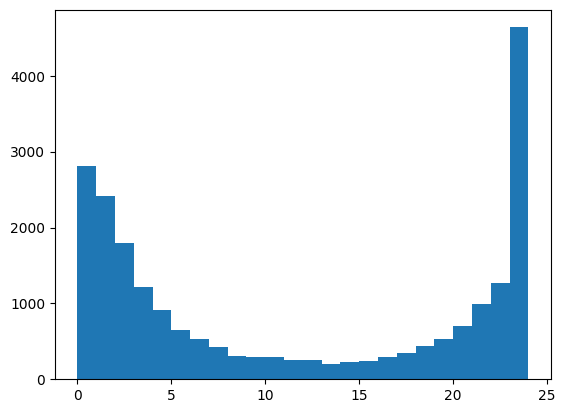

In [5]:
x = plt.hist(np.sum(ising_samples, axis = 1), bins = np.arange(0,25,1))

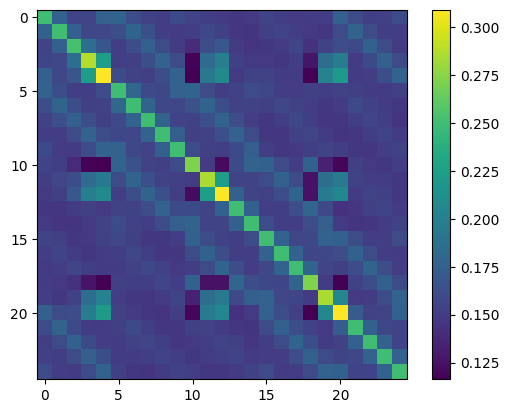

In [6]:
plt.imshow(np.cov(ising_samples.T))
plt.colorbar()

In [7]:
ising_samples.shape

(24999, 25)

In [ ]:
from pathlib import Path

out_dir = Path("datasets")
out_dir.mkdir(parents=True, exist_ok=True)

tag = f"ising_L{L}_T{TEMP:g}_h{h:g}"
path = out_dir / f"{tag}.npy"

np.save(path, ising_samples)
print(f"Saved: {path})")

Saved: datasets/ising_L5_T2.4_h0.08.npy)
